In [1]:
import sys
sys.path.append('../../1_figure_CL_proof_of_concept/code/')
import utils_00 as gf_utils
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import scanpy as sc
import seaborn as sns
import scipy.stats as st
import matplotlib.patches as mpatches

large_data_dir = gf_utils.large_data_dir
matplotlib.rcParams['pdf.fonttype'] = 42


In [ ]:
adata = sc.read_h5ad(large_data_dir + 'MPN_WTA/Integrated_MPN_scvi_genotyped_nb.h5ad')
adata = adata[adata.obs['cell_type'] != 'Monocyte/Platelet doublet (non-HSPC)']

In [3]:
adata.obs['coarse_cell_type'] = adata.obs['PBMC_cell_types'].astype('category')

T = ['CD8 Memory','CD8 Naive','CD4 Naive','CD4 Memory','Treg']
DC = ['cDC','pDC']

# Add new categories 'T' and 'DC' if not already present
if 'T' not in adata.obs['coarse_cell_type'].cat.categories:
    adata.obs['coarse_cell_type'] = adata.obs['coarse_cell_type'].cat.add_categories(['T'])
if 'DC' not in adata.obs['coarse_cell_type'].cat.categories:
    adata.obs['coarse_cell_type'] = adata.obs['coarse_cell_type'].cat.add_categories(['DC'])
if 'Neutrophil-like' not in adata.obs['coarse_cell_type'].cat.categories:
    adata.obs['coarse_cell_type'] = adata.obs['coarse_cell_type'].cat.add_categories(['Neutrophil-like'])
    
adata.obs.loc[adata.obs['coarse_cell_type'].isin(T), 'coarse_cell_type'] = 'T'
adata.obs.loc[adata.obs['coarse_cell_type'].isin(DC), 'coarse_cell_type'] = 'DC'
adata.obs.loc[adata.obs['cell_type'].str.contains('Neutrophil'), 'coarse_cell_type'] = 'Neutrophil-like'
adata.obs.loc[~adata.obs['cell_type'].str.contains('(non-HSPC)'), 'coarse_cell_type'] = 'HSPC'


/tmp/ipykernel_2026795/2497028329.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['coarse_cell_type'] = adata.obs['PBMC_cell_types'].astype('category')
/tmp/ipykernel_2026795/2497028329.py:17: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  adata.obs.loc[~adata.obs['cell_type'].str.contains('(non-HSPC)'), 'coarse_cell_type'] = 'HSPC'


In [4]:
to_include = adata.obs['coarse_cell_type'].value_counts(normalize=True)
to_include = to_include[to_include > 0.03].index.tolist()


In [5]:
color_palette = {}
color_palette['HSPC'] = '#1f77b4'
color_palette['T'] = '#e377c2'
color_palette['DC'] = '#ffbb78'
color_palette['B'] = '#17becf'
color_palette['CD14 Monocytes'] = '#ff7f0e'
color_palette['CD16 Monocytes'] = '#9467bd'
color_palette['Neutrophil-like'] = '#aec7e8'
color_palette['All'] = 'k'


In [6]:
variant = 'JAK2 c.1849G>T'
# Get all unique patients
patients = adata.obs['patient'].unique()
prop_genotyped_list = []
condition = adata.obsm['genotypes'][variant + '_high_confidence_counts'] > 0
for patient in patients:
    patient_condition = (adata.obs['patient'] == patient)
    n_patient = len(adata[patient_condition].obs)
    n_patient_condition = len(adata[patient_condition & condition].obs)
    prop = n_patient_condition / n_patient if n_patient > 0 else float('nan')
    prop_genotyped_list.append({'patient': patient, 'prop_genotyped': prop})

prop_genotyped_df = pd.DataFrame(prop_genotyped_list)
prop_genotyped_df = prop_genotyped_df.loc[prop_genotyped_df['prop_genotyped'] > 0] ### remove any that are 0 as this means probe probably was not included (be careful with variants with very low prop genotyped)

print('prop genotyped', condition.value_counts(normalize=True)[True])
print('mean genotyped', prop_genotyped_df['prop_genotyped'].mean())
print('median genotyped', prop_genotyped_df['prop_genotyped'].median())


# Get props by cell type
patients = adata.obs['patient'].unique()
prop_genotyped_list = []

condition = adata.obsm['genotypes'][variant + '_high_confidence_counts'] > 0
for patient in patients:
    patient_condition = (adata.obs['patient'] == patient)
    for cell_type in to_include:
        cell_type_condition = (adata.obs['coarse_cell_type'] == cell_type)
        n_patient_cell_type = len(adata[patient_condition & cell_type_condition].obs)
        n_patient_condition_cell_type = len(adata[patient_condition & condition & cell_type_condition].obs)
        prop = n_patient_condition_cell_type / n_patient_cell_type if n_patient_cell_type > 0 else float('nan')
        prop_genotyped_list.append({'patient': patient, 'cell_type': cell_type, 'prop_genotyped': prop})

prop_genotyped_by_cell_type_df = pd.DataFrame(prop_genotyped_list)
prop_genotyped_by_cell_type_df = prop_genotyped_by_cell_type_df.loc[prop_genotyped_by_cell_type_df['patient'].isin(prop_genotyped_df['patient'])].copy()

prop_genotyped_df['cell_type'] = 'All'
to_plot = pd.concat([prop_genotyped_by_cell_type_df, prop_genotyped_df]).dropna()
n_cells = adata.obs['coarse_cell_type'].value_counts(normalize=False)[to_include]
order = ['All'] + to_include
n_cells['All'] = len(adata.obs)
n_cells = n_cells.reindex(order)


prop genotyped 0.2646211959633151
mean genotyped 0.24292653591428826
median genotyped 0.2640061141755832


/tmp/ipykernel_2026795/3944614007.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  gene_counts = adata.obs.groupby(['patient','coarse_cell_type'])['expression_count'].mean().reset_index().dropna()


SignificanceResult(statistic=0.9321939602818299, pvalue=5.779820699250819e-96)


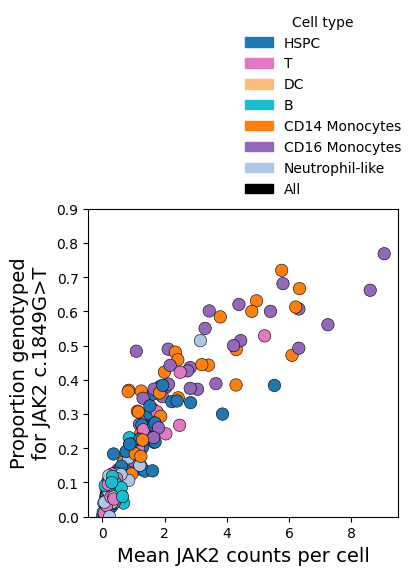

In [8]:
gene = variant.split(' ')[0]  # Extract the gene name from the variant string

expression_counts_series = pd.Series(
    data=adata[:, gene].layers['raw_data'].toarray().flatten() if hasattr(adata[:, gene].X, 'toarray') else adata[:, gene].X.flatten(),
    index=adata.obs.index,
    name='counts'
)

adata.obs['expression_count'] = expression_counts_series


prop_genotyped_by_cell_type_df = pd.DataFrame(prop_genotyped_list)
prop_genotyped_by_cell_type_df = prop_genotyped_by_cell_type_df.loc[prop_genotyped_by_cell_type_df['patient'].isin(prop_genotyped_df['patient'])].copy()
gene_counts = adata.obs.groupby(['patient','coarse_cell_type'])['expression_count'].mean().reset_index().dropna()
gene_counts.rename(columns={'coarse_cell_type': 'cell_type'}, inplace=True)
prop_genotyped_by_cell_type_df = prop_genotyped_by_cell_type_df.merge(gene_counts, on=['patient', 'cell_type'], how='left').copy()
prop_genotyped_by_cell_type_df.dropna(inplace=True)



x = prop_genotyped_by_cell_type_df['expression_count']
y = prop_genotyped_by_cell_type_df['prop_genotyped']

colors = prop_genotyped_by_cell_type_df['cell_type'].map(color_palette)
fig,ax = plt.subplots(figsize = (4,4))
ax.scatter(x,y, c=colors, edgecolors='k', s=80, linewidths=0.4)
ax.set_xlabel('Mean ' + gene + ' counts per cell', size=14)
ax.set_ylabel('Proportion genotyped\nfor ' + variant, size=14)

ax.set_ylim(0,0.9)


# Create legend handles from color_palette
handles = [mpatches.Patch(color=color, label=ct) for ct, color in color_palette.items()]
ax.legend(handles=handles, title='Cell type', bbox_to_anchor=(1.05, 1), loc='lower right', frameon=False)

print(st.spearmanr(x,y))

plt.savefig('../plots/JAK2_capture_vs_expression_scatter.pdf', bbox_inches='tight')
